In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC


In [2]:
#Read in csv and output head to see dataset
heart = pd.read_csv("heart.csv")

heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
#Rows and columns
heart.shape

(918, 12)

In [4]:
#data types and non-null count
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
#Descriptive stats
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
#missing values info
heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
#Number of unique values
for column in heart.columns:
    unique_values = len(heart[column].unique())
    print(f"Number of unique values in {column}: {unique_values}")

Number of unique values in Age: 50
Number of unique values in Sex: 2
Number of unique values in ChestPainType: 4
Number of unique values in RestingBP: 67
Number of unique values in Cholesterol: 222
Number of unique values in FastingBS: 2
Number of unique values in RestingECG: 3
Number of unique values in MaxHR: 119
Number of unique values in ExerciseAngina: 2
Number of unique values in Oldpeak: 53
Number of unique values in ST_Slope: 3
Number of unique values in HeartDisease: 2


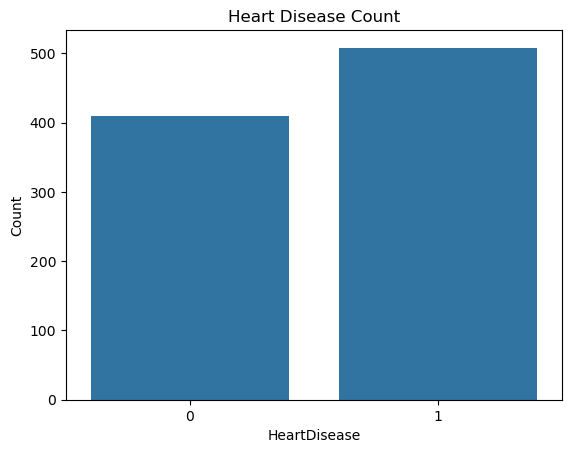

In [9]:
##EDA
#Count of heart disease
sns.countplot(data = heart, x = "HeartDisease")
plt.title("Heart Disease Count")
plt.xlabel("HeartDisease")
plt.ylabel("Count")
plt.show()

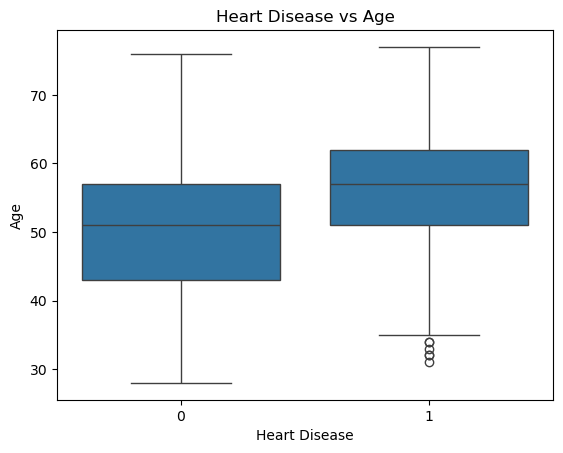

In [10]:
#Age vs HeartDisease
sns.boxplot(data = heart, y = "Age", x = "HeartDisease")
plt.title("Heart Disease vs Age")
plt.ylabel("Age")
plt.xlabel("Heart Disease")
plt.show()

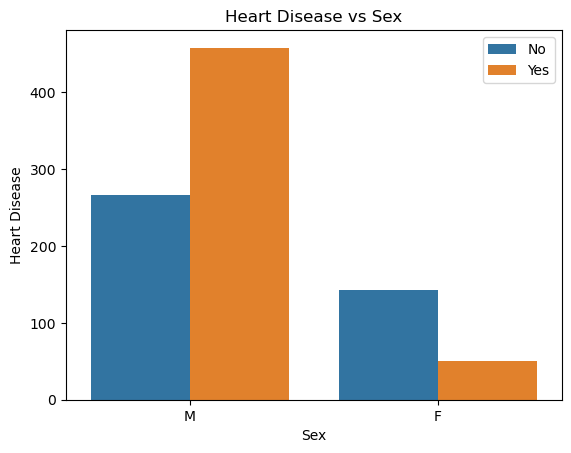

In [11]:
#Age vs HeartDisease
sns.countplot(data = heart, hue = "HeartDisease", x = "Sex")
plt.title("Heart Disease vs Sex")
plt.xlabel("Sex")
plt.ylabel("Heart Disease")
plt.legend(["No", "Yes"])
plt.show()

<Axes: xlabel='ChestPainType', ylabel='count'>

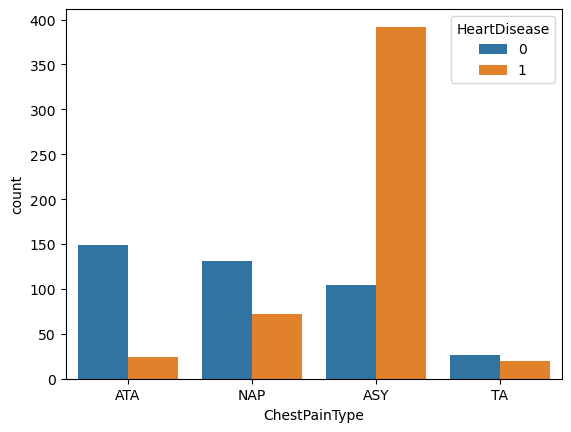

In [12]:
#ChestPain vs Heart Disease 
sns.countplot(
    x=heart["ChestPainType"], 
    hue=heart["HeartDisease"],
    legend=True
)

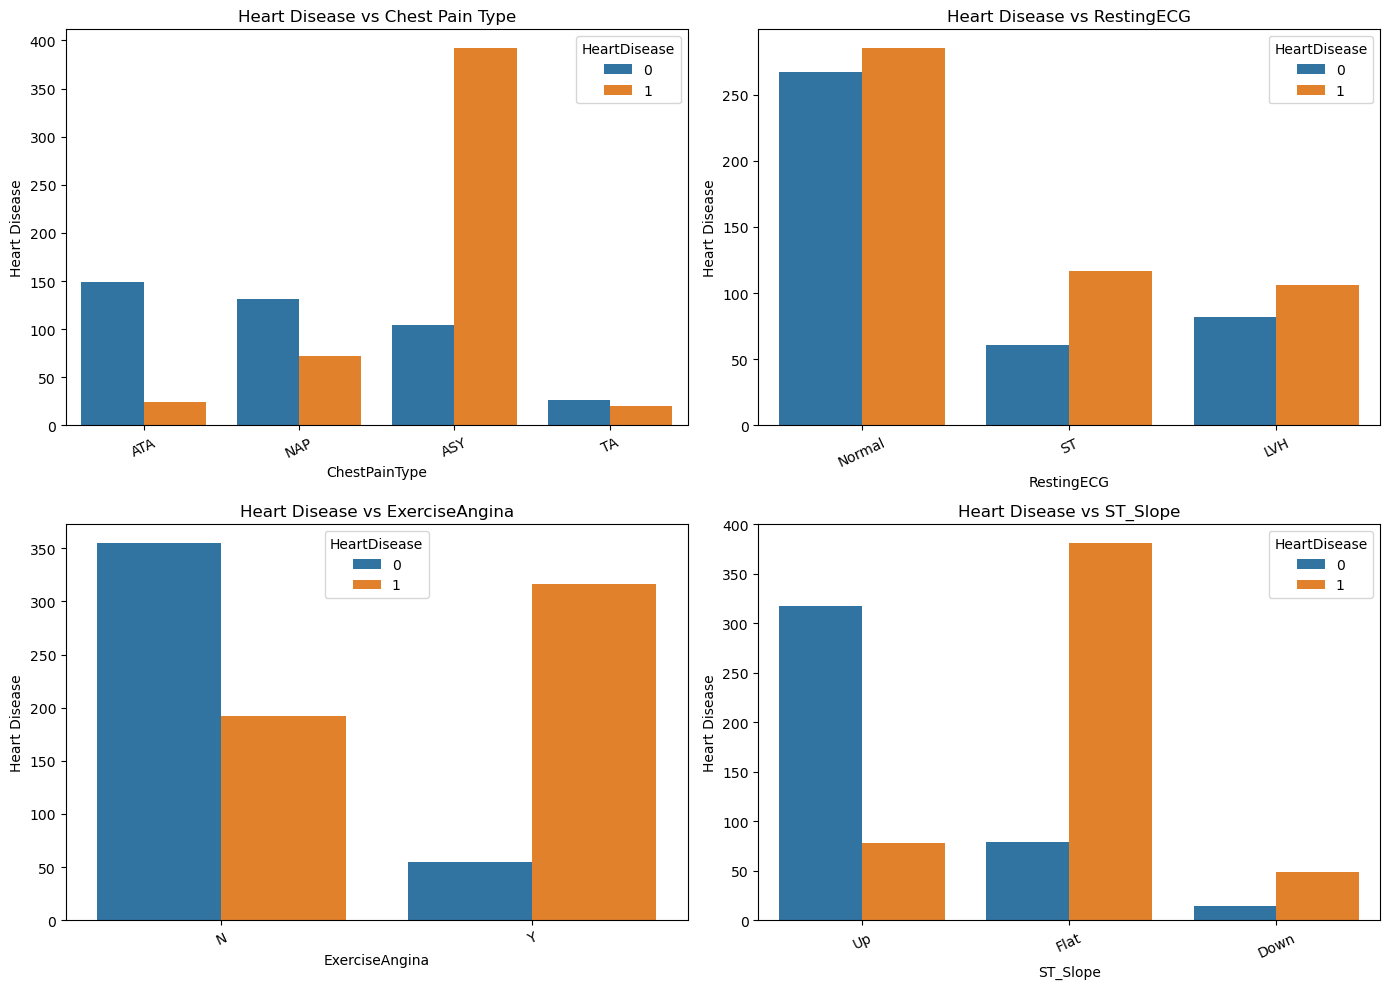

In [13]:
#Count plots of each categorical variable vs heartdisease

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    x=heart["ChestPainType"], 
    ax=axes[0, 0],
    hue=heart["HeartDisease"],
    legend=True
)
axes[0, 0].set_title("Heart Disease vs Chest Pain Type")
axes[0, 0].set_xlabel("ChestPainType")
axes[0, 0].set_ylabel("Heart Disease")
axes[0, 0].tick_params(axis='x', rotation=25)

# --- Second plot ---
sns.countplot(
    x=heart["RestingECG"], 
    ax=axes[0, 1],
    hue=heart["HeartDisease"],
    legend=True
)
axes[0, 1].set_title("Heart Disease vs RestingECG")
axes[0, 1].set_xlabel("RestingECG")
axes[0, 1].set_ylabel("Heart Disease")
axes[0, 1].tick_params(axis='x', rotation=25)

# --- Third plot ---
sns.countplot(
    x=heart["ExerciseAngina"], 
    ax=axes[1, 0],
    hue=heart["HeartDisease"],
    legend=True
)
axes[1, 0].set_title("Heart Disease vs ExerciseAngina")
axes[1, 0].set_xlabel("ExerciseAngina")
axes[1, 0].set_ylabel("Heart Disease")
axes[1, 0].tick_params(axis='x', rotation=25)

# --- Fourth plot ---
sns.countplot(
    x=heart["ST_Slope"], 
    ax=axes[1, 1],
    hue=heart["HeartDisease"],
    legend=True
)
axes[1, 1].set_title("Heart Disease vs ST_Slope")
axes[1, 1].set_xlabel("ST_Slope")
axes[1, 1].set_ylabel("Heart Disease")
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

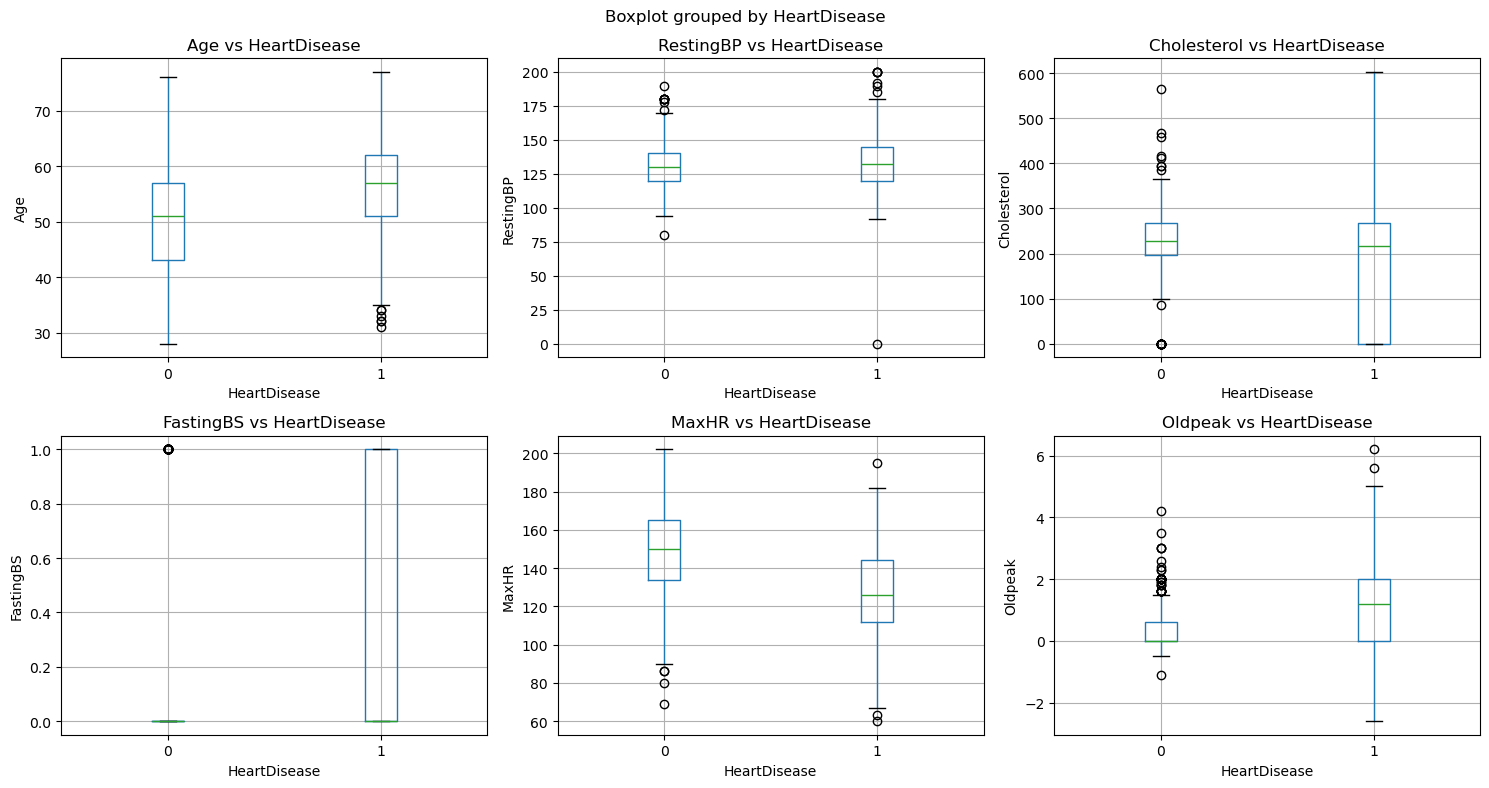

In [14]:
#Boxplots of each numeric variables
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax = ax.ravel()

for i, col in enumerate(numeric_cols):
    heart.boxplot(column=col, by="HeartDisease", ax=ax[i])
    ax[i].set_title(f"{col} vs HeartDisease")
    ax[i].set_xlabel("HeartDisease")
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

<Axes: >

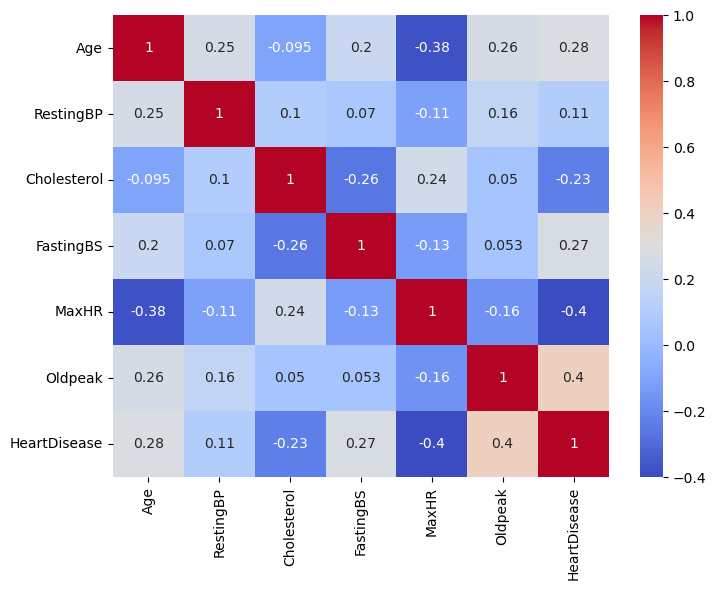

In [15]:
#Correlations between numeric variables and target variable
numericheart = heart.select_dtypes(include = ["int64","float64"])
correlation = numericheart.corr()

plt.figure(figsize = (8,6))
sns.heatmap(correlation, annot = True, cmap = "coolwarm")

In [16]:
heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [17]:
#Data Preprocessing
#Split into numeric and categorical variables

numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [18]:
#Transform to encode and scale features

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown = "ignore")

preprocess = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
   ]
)

decisiontree_preprocess = ColumnTransformer(
    transformers = [
        ("cat", categorical_transformer, categorical_cols)
   ]
)


In [19]:
#Model Building

#Pipeline for model

logreg_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocess),
        ("model", LogisticRegression())
    ]
)

svm_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocess),
        ("model", SVC())
    ]
)

decisiontree_pipeline = Pipeline(
    steps = [
        ("preprocessor", decisiontree_preprocess),
        ("model", DecisionTreeClassifier())
    ]
)



In [20]:
X = heart.drop(columns = ["HeartDisease"])
y = heart["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [21]:
#Hyperparameter tuning
logreg_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear"],  # supports l1/l2
    "model__max_iter": [200, 500]
}

svm_grid = {
    "model__C": [0.1, 1, 10, 50],
    "model__kernel": ["linear", "rbf", "poly"],
    "model__gamma": ["scale", "auto"]
}

decisiontree_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [22]:
logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_grid,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

decisiontree_search = GridSearchCV(
    estimator=decisiontree_pipeline,
    param_grid=decisiontree_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [23]:
logreg_search.fit(X_train, y_train)

svm_search.fit(X_train, y_train)

decisiontree_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'ChestPainType',
                                                                          'RestingECG',
                                                                          'ExerciseAngina',
                                                                          'ST_Slope'])])),
                                       ('model', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [3, 5, 10, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [24]:
logreg_model = logreg_search.best_estimator_

svm_model = svm_search.best_estimator_

decisiontree_model = decisiontree_search.best_estimator_


In [25]:
logreg_pred = logreg_model.predict(X_test)

svm_y_pred = svm_model.predict(X_test)

decisiontree_y_pred = decisiontree_model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, logreg_pred))
print("Precision:", precision_score(y_test, logreg_pred))
print("Recall:", recall_score(y_test, logreg_pred))
print("F1 Score:", f1_score(y_test, logreg_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, logreg_pred))
print("\nClassification Report:\n", classification_report(y_test, logreg_pred))

Accuracy: 0.8586956521739131
Precision: 0.9090909090909091
Recall: 0.8411214953271028
F1 Score: 0.8737864077669902

Confusion Matrix:
 [[68  9]
 [17 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [27]:
svm_pipeline.fit(X_train, y_train)

svm_y_pred = svm_pipeline.predict(X_test)

print("Precision:", precision_score(y_test, svm_y_pred))
print("Recall:", recall_score(y_test, svm_y_pred))
print("F1 Score:", f1_score(y_test, svm_y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_y_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_y_pred))

Precision: 0.8867924528301887
Recall: 0.8785046728971962
F1 Score: 0.8826291079812206

Confusion Matrix:
 [[65 12]
 [13 94]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.84        77
           1       0.89      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [28]:
decisiontree_pipeline.fit(X_train, y_train)

decisiontree_y_pred = decisiontree_pipeline.predict(X_test)

print("Precision:", precision_score(y_test, decisiontree_y_pred))
print("Recall:", recall_score(y_test, decisiontree_y_pred))
print("F1 Score:", f1_score(y_test, decisiontree_y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, decisiontree_y_pred))
print("\nClassification Report:\n", classification_report(y_test, decisiontree_y_pred))

Precision: 0.9010989010989011
Recall: 0.7663551401869159
F1 Score: 0.8282828282828283

Confusion Matrix:
 [[68  9]
 [25 82]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.88      0.80        77
           1       0.90      0.77      0.83       107

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.81       184
weighted avg       0.83      0.82      0.82       184

